# Weight Generator

This notebook develops a pipeline for generating synthetic SKU weights that faithfully reproduces
the statistical properties of the real weight distribution.  We fit a body–tail
mixture model and, as an alternative, a single log-normal mixture over the full
range.

### Pipeline overview


| Step | Description | Output |
|------|-------------|--------|
| **1** | Setup and Data Loading | - |
| **2** | Exploratory Data Analysis | - |
| **3** | Implement body-tail decomposition | Body model $f_{\text{body}}$, tail model $F_{\text{GPD}}$ |
| **4** | Calibrate threshold $w_0$ and mixture components $K$ | Calibrated $w_0$, $K$, mixture parameters |
| **5** | Inspect calibrated models | - |
| **6** | Sample synthetic weights from body-tail or full mixture | Synthetic weight samples |
| **7** | Alternative: full-data mixture | Full mixture parameters $\Theta_{\text{full}}$ |
| **8** | Final calibrated parameters | Parameter sets $\Theta_{\text{body-tail}}$, $\Theta_{\text{full}}$ |
| **9** | Quality Assessment | - |


## 1. Setup & Data Loading

### 1.1 Configuration

In [1]:
# CONFIGURATION

# Seed
SEED = 42

# Data path
RAW_DATA_PATH = "../../../data_files/raw"

# Output paths
OUTPUTS_PATH = "outputs/intermediate"
MODELS_PATH = "outputs/generated_models"

# Candidate threshold percentiles to sweep
CANDIDATE_PERCENTILES_START = 70
CANDIDATE_PERCENTILES_END   = 100
CANDIDATE_PERCENTILES_STEP  = 5

# Sampling budget per candidate
N_CALIB_SAMPLES  = 100_000
N_CALIB_REPEATS  = 5

# Candidates for the number of mixture components
K_MIN = 1
K_MAX = 10

# Stability penalty weight
LAMBDA_STAB = 0.25
N_INIT_STABILITY = 5

# Number of SKUs to generate (must match distance_generator and cost_generator)
n_skus = 10

# Number of SKUs to generate in the final quality-assessment section
N_TEST_SKUS = None  # set to None to use len(weights_real)

### 1.2 Imports & Data Loading

In [2]:
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

rng = np.random.default_rng(SEED)

In [3]:
path = Path(RAW_DATA_PATH)  
skus_df = pd.read_csv(path / "06_skus.csv")
weights_real = skus_df["weight"].values

print(f"Loaded {len(weights_real):,} SKU weights")
print(f"  Min:    {weights_real.min():.4f}")
print(f"  Max:    {weights_real.max():.4f}")
print(f"  Mean:   {weights_real.mean():.4f}")
print(f"  Median: {np.median(weights_real):.4f}")
print(f"  Std:    {weights_real.std():.4f}")

Loaded 10,578 SKU weights
  Min:    0.6947
  Max:    1263.7453
  Mean:   58.0137
  Median: 2.4891
  Std:    153.8762


## 2. Exploratory Data Analysis

Before modelling, we inspect the empirical weight distribution.  Key features
to look for: heavy right skew, a concentration of light SKUs near zero, and a
long tail of heavy items.

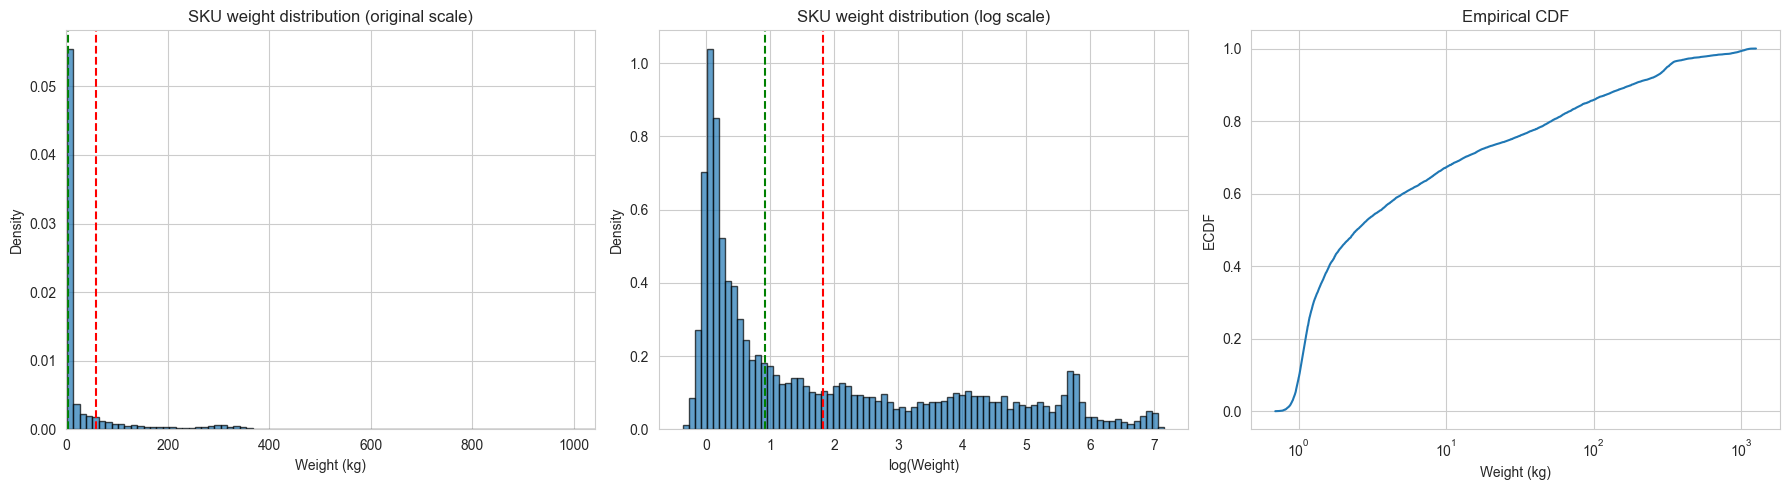

Key percentiles of the real weight data:
  P 50.0:     2.4891
  P 75.0:    27.7156
  P 80.0:    51.8517
  P 85.0:    89.5868
  P 90.0:   180.9090
  P 95.0:   318.1519
  P 99.0:   947.1616
  P 99.5:  1044.3213

Skewness:  4.33
Kurtosis:  21.53


In [4]:
# DATA ANALYSIS & PLOTS

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw histogram
axes[0].hist(weights_real, bins=100, density=True, alpha=0.7, edgecolor="black")
axes[0].set_xlabel("Weight (kg)")
axes[0].set_ylabel("Density")
axes[0].set_title("SKU weight distribution (original scale)")
axes[0].set_xlim(0, np.percentile(weights_real, 99) * 1.1)
axes[0].axvline(np.mean(weights_real), color="r", ls="--", label=f"Mean {np.mean(weights_real):.1f}")
axes[0].axvline(np.median(weights_real), color="g", ls="--", label=f"Median {np.median(weights_real):.1f}")

# Log-scale histogram
log_weights = np.log(weights_real[weights_real > 0])
axes[1].hist(log_weights, bins=80, density=True, alpha=0.7, edgecolor="black")
axes[1].set_xlabel("log(Weight)")
axes[1].set_ylabel("Density")
axes[1].set_title("SKU weight distribution (log scale)")
axes[1].axvline(np.mean(log_weights), color="r", ls="--", label=f"Mean {np.mean(log_weights):.1f}")
axes[1].axvline(np.median(log_weights), color="g", ls="--", label=f"Median {np.median(log_weights):.1f}")


# ECDF
sorted_w = np.sort(weights_real)
ecdf_y = np.arange(1, len(sorted_w) + 1) / len(sorted_w)
axes[2].plot(sorted_w, ecdf_y, lw=1.5)
axes[2].set_xlabel("Weight (kg)")
axes[2].set_ylabel("ECDF")
axes[2].set_title("Empirical CDF")
axes[2].set_xscale("log")

plt.tight_layout()
plt.show()

# Key percentiles
percentiles = [50, 75, 80, 85, 90, 95, 99, 99.5]
print("Key percentiles of the real weight data:")
for p in percentiles:
    print(f"  P{p:5.1f}: {np.percentile(weights_real, p):10.4f}")

print(f"\nSkewness:  {stats.skew(weights_real):.2f}")
print(f"Kurtosis:  {stats.kurtosis(weights_real):.2f}")

## 3. Body–Tail Decomposition

The real weight distribution has a heavy right tail that a single parametric
family cannot capture well.  We therefore split the distribution at a threshold
$w_0$ into two regions:

| Region | Range | Model | Parameters |
|--------|-------|-------|------------|
| **Body** | $w_{\min} \leq w \leq w_0$ | Truncated $K$-component log-normal mixture | $\{\pi_k,\mu_k,\sigma_k\}_{k=1}^{K}\ \text{with}\ \sum_{k=1}^{K}\pi_k=1$ |
| **Tail** | $w > w_0$ | Truncated Generalized Pareto Distribution (GPD) on exceedances $y = w - w_0$ | $\xi, \beta$ |

A **Bernoulli** draw with $p_{\text{tail}} = \Pr(W > w_0)$ decides which
region each synthetic SKU is sampled from.

### Body model
For a candidate threshold $w_0$, the body consists of all weights $\leq w_0$.
We fit a $K$-component log-normal mixture to these values in log-space and then
sample from its PDF via truncated mixture sampling on $[w_{\min}, w_0]$.

$$f_{\text{body}}(\log w) = \sum_{k=1}^{K} \pi_k \,\mathcal{N}(\log w \mid \mu_k, \sigma_k^2), \qquad w_{\min} \leq w \leq w_0$$

Our truncated sampling approach uses the hierarchical inverse-CDF method: First pick component $k$ from $\text{Categorical}(\pi_1, \dots, \pi_K)$ and then sample from the corresponding truncated log-normal via $w = \exp\!\bigl(\mu_k + \sigma_k \,\Phi^{-1}(u)\bigr)$ where $u$ is uniform on the CDF interval $[\Phi(\log w_{\min}), \Phi(\log w_0)]$.

### Tail model
For weights above the threshold $w_0$, we explicitly model the extreme tail rather than forcing the body distribution to explain very heavy SKUs. Concretely, for any sampled weight $W$ with $W>w_0$, we switch to exceedance space $Y = W - w_0 \:\text{s.t.}\: Y \ge 0,$ and model $Y$ with a Generalized Pareto Distribution (GPD). This is the standard “body–tail” decomposition where the truncated log-normal mixture captures the bulk of ordinary items up to $w_0$, while the GPD captures the slower decay (heavier probability mass) of extreme weights beyond $w_0$. 


We estimate the GPD parameters $(\xi, \beta)$ from the empirical exceedances $Y$ above the threshold $w_0$ using Maximum likelihood estimation (MLE). While $\xi$ (shape) influences how heavy the tail is, $\beta$ (scale) controls the typical magnitude / spread of exceedances. The truncated GPD is sampled in exceedance space using its CDF: 


$$F_{\text{GPD}}(y;\,\xi,\beta) = 1 - \bigl(1 + \xi\,y/\beta\bigr)^{-1/\xi}, \qquad 0 \leq y \leq w_{\max} - w_0$$

Sampling again uses the inverse-CDF method with truncation at $w_{\max} - w_0$. Draws are finally shifted back by $w_0$.

The cell below defines all helper functions needed for fitting and sampling
both models.

In [5]:
# HELPERS

def _sample_truncated_lognormal(
    mu: float, sigma: float,
    lo: float, hi: float,
    size: int, rng: np.random.Generator,
) -> np.ndarray:
    """
    Samples from LogNormal(mu, sigma) truncated to [lo, hi] via inverse CDF.

    Args:
        mu (float): Log-space mean of the log-normal distribution.
        sigma (float): Log-space std of the log-normal distribution.
        lo (float): Lower truncation bound.
        hi (float): Upper truncation bound.
        size (int): Number of samples to draw.
        rng (np.random.Generator): Random number generator.

    Returns:
        samples (np.ndarray): Sample array of shape (size,).
    """
    Phi     = stats.norm.cdf
    Phi_inv = stats.norm.ppf
    log_lo, log_hi = np.log(lo), np.log(hi)
    a = Phi((log_lo - mu) / sigma)
    b = Phi((log_hi - mu) / sigma)
    u = rng.uniform(a, b, size=size)
    z = Phi_inv(u)
    return np.exp(mu + sigma * z)

def sample_truncated_lognormal_mixture(
    mix_weights: np.ndarray,
    means: np.ndarray,
    stds: np.ndarray,
    lo: float, hi: float,
    size: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Hierarchical inverse-CDF sampling from a truncated log-normal mixture.

    Args:
        mix_weights (np.ndarray): Mixture weights. Shape: (K,).
        means (np.ndarray): Component means in log-space. Shape: (K,).
        stds (np.ndarray): Component stds in log-space. Shape: (K,).
        lo (float): Lower truncation bound.
        hi (float): Upper truncation bound.
        size (int): Number of samples to draw.
        rng (np.random.Generator): Random number generator.

    Returns:
        samples (np.ndarray): Sample array of shape (size,).
    """
    components = rng.choice(len(mix_weights), size=size, p=mix_weights)
    samples = np.empty(size)
    for k in range(len(mix_weights)):
        mask = components == k
        n_k = mask.sum()
        if n_k > 0:
            samples[mask] = _sample_truncated_lognormal(
                means[k], stds[k], lo, hi, n_k, rng,
            )
    return samples

def fit_lognormal_mixture_body(
    weights: np.ndarray, w0: float, n_components: int = 2,
) -> dict:
    """
    Fits a K-component log-normal mixture to the body (weights <= w0).

    Args:
        weights (np.ndarray): Observed weights. Shape: (N,).
        w0 (float): Threshold; only weights <= w0 are used.
        n_components (int): Number of mixture components. Default: 2.

    Returns:
        params (dict): Dict with mix_weights, means, stds, n_components, w_min, w0.
    """
    body = weights[(weights <= w0) & np.isfinite(weights) & (weights > 0)]
    log_body = np.log(body).reshape(-1, 1)
    gm = GaussianMixture(
        n_components=n_components, random_state=42,
        n_init=10, max_iter=500, reg_covar=1e-6,
    )
    gm.fit(log_body)
    return {
        "mix_weights": gm.weights_,
        "means": gm.means_.flatten(),
        "stds": np.sqrt(gm.covariances_.flatten()),
        "n_components": n_components,
        "w_min": body.min(),
        "w0": w0,
    }

def fit_gpd_tail(weights: np.ndarray, w0: float) -> dict:
    """
    Fits a GPD to exceedances (weights - w0) for weights > w0.

    Args:
        weights (np.ndarray): Observed weights. Shape: (N,).
        w0 (float): Threshold; only weights > w0 are used.

    Returns:
        params (dict): Dict with xi, beta, w0, w_max.
    """
    exceedances = weights[weights > w0] - w0
    xi, _, beta = stats.genpareto.fit(exceedances, floc=0)
    return {"xi": xi, "beta": beta, "w0": w0, "w_max": weights.max()}

def sample_truncated_gpd(
    xi: float, beta: float, upper: float,
    size: int, rng: np.random.Generator,
) -> np.ndarray:
    """
    Samples from GPD(xi, beta) truncated to [0, upper] via inverse CDF.

    Args:
        xi (float): GPD shape parameter.
        beta (float): GPD scale parameter.
        upper (float): Upper truncation bound (in exceedance space).
        size (int): Number of samples to draw.
        rng (np.random.Generator): Random number generator.

    Returns:
        samples (np.ndarray): Exceedance samples of shape (size,).
    """
    cdf_upper = stats.genpareto.cdf(upper, xi, scale=beta)
    u = rng.uniform(0.0, cdf_upper, size=size)
    return stats.genpareto.ppf(u, xi, scale=beta)

def sample_gmm_lognormal_1d(
    gm: GaussianMixture, size: int, rng: np.random.Generator,
    log_lo: float = -np.inf, log_hi: float = np.inf,
) -> np.ndarray:
    """
    Samples from a fitted 1-D GMM in log-space, returns weights in original scale.

    Args:
        gm (GaussianMixture): Fitted GMM in log-space.
        size (int): Number of samples to draw.
        rng (np.random.Generator): Random number generator.
        log_lo (float): Lower bound in log-space. Default: -inf.
        log_hi (float): Upper bound in log-space. Default: inf.

    Returns:
        samples (np.ndarray): Weight samples of shape (size,).
    """
    return sample_truncated_lognormal_mixture(
        gm.weights_, gm.means_.flatten(),
        np.sqrt(gm.covariances_.flatten()),
        np.exp(log_lo), np.exp(log_hi), size, rng,
    )

def quantile_error_log(
    real: np.ndarray, gen: np.ndarray,
    q_grid: np.ndarray | None = None,
) -> float:
    """
    Mean absolute error between log-quantiles of real and generated samples.

    Args:
        real (np.ndarray): Real data. Shape: (N,).
        gen (np.ndarray): Generated data. Shape: (M,).
        q_grid (np.ndarray | None): Quantile levels. Default: [0.01, 0.05, ..., 0.99].

    Returns:
        mae (float): Mean absolute error in log-quantile space.
    """
    if q_grid is None:
        q_grid = np.array([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    real_q = np.log(np.maximum(np.quantile(real, q_grid), 1e-12))
    gen_q  = np.log(np.maximum(np.quantile(gen,  q_grid), 1e-12))
    return float(np.mean(np.abs(real_q - gen_q)))

def sorted_params(gm: GaussianMixture):
    """
    Sorts mixture components by mean to avoid label switching.

    Args:
        gm (GaussianMixture): Fitted GMM.

    Returns:
        weights (np.ndarray): Sorted mix weights. Shape: (K,).
        means (np.ndarray): Sorted means. Shape: (K,).
        stds (np.ndarray): Sorted stds. Shape: (K,).
    """
    m = gm.means_.flatten()
    order = np.argsort(m)
    return gm.weights_[order], m[order], np.sqrt(gm.covariances_.flatten())[order]

def robust_z(x: np.ndarray) -> np.ndarray:
    """
    Robust z-scores using median and MAD.

    Args:
        x (np.ndarray): Input array. Shape: (N,).

    Returns:
        z (np.ndarray): Robust z-scores. Shape: (N,).
    """
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad < 1e-12:
        return np.zeros_like(x)
    return (x - med) / (mad * 1.4826)

def compute_summary_stats(w: np.ndarray) -> dict:
    """
    Summary statistics for distribution comparison.

    Args:
        w (np.ndarray): Sample array. Shape: (N,).

    Returns:
        stats (dict): Dict with mean, median, std, skew, kurtosis, p25, p75, p90, p95, p99, max.
    """
    return {
        "mean": np.mean(w), "median": np.median(w), "std": np.std(w),
        "skew": stats.skew(w), "kurtosis": stats.kurtosis(w),
        "p25": np.percentile(w, 25), "p75": np.percentile(w, 75),
        "p90": np.percentile(w, 90), "p95": np.percentile(w, 95),
        "p99": np.percentile(w, 99), "max": np.max(w),
    }

def relative_error(real_stats: dict, gen_stats: dict) -> float:
    """
    Mean absolute relative error across all summary statistics.

    Args:
        real_stats (dict): Summary stats from real data.
        gen_stats (dict): Summary stats from generated data.

    Returns:
        mae_rel (float): Mean absolute relative error.
    """
    errs = []
    for key in real_stats:
        ref = abs(real_stats[key])
        if ref < 1e-9:
            continue
        errs.append(abs(real_stats[key] - gen_stats[key]) / ref)
    return float(np.mean(errs))

## 4. Automatic Calibration (Threshold & K Selection)

The body model requires choosing both a threshold $w_0$ and the number of
mixture components $K$.  Rather than picking these by hand, we run a
calibration sweep:

1. For each candidate percentile $p \in \{70, 80, \dots, 95\}$, set $w_0 = Q_p$.
2. Auto-select $K$ for that $w_0$ using BIC, AIC, held-out log-likelihood,
   quantile error, and a stability penalty.
3. Fit body + tail, generate a large unconditional sample, and compute a
   composite relative error vs. the real summary statistics.
4. Pick the $(w_0, K)$ pair with the lowest error.

This resolves the circular dependency between $K$ and $w_0$.

In [7]:
# HELPERS

def select_optimal_K(
    weights: np.ndarray,
    w0: float,
    rng: np.random.Generator,
    K_candidates: list | None = None,
    n_init_stability: int = N_INIT_STABILITY,
    n_q_samples: int = 100_000,
    q_grid: np.ndarray | None = None,
    lambda_stab: float = LAMBDA_STAB,
    return_metrics: bool = False,
) -> dict:
    """
    Selects optimal K for the body log-normal mixture via BIC, AIC,
    held-out log-likelihood, quantile fit, and a soft stability penalty.

    Args:
        weights (np.ndarray): Observed weights. Shape: (N,).
        w0 (float): Threshold; only weights <= w0 are used for body.
        rng (np.random.Generator): Random number generator.
        K_candidates (list | None): Candidate K values. Default: [K_MIN, ..., K_MAX].
        n_init_stability (int): Number of stability-fit replicates. Default: N_INIT_STABILITY.
        n_q_samples (int): Samples for quantile error evaluation. Default: 100_000.
        q_grid (np.ndarray | None): Quantile levels. Default: [0.01, ..., 0.99].
        lambda_stab (float): Stability penalty weight. Default: LAMBDA_STAB.
        return_metrics (bool): If True, also return BIC, AIC, heldout_ll, quant_errs, penalty. Default: False.

    Returns:
        result (dict): Dict with selected_K. If return_metrics=True, also includes
            K_candidates, bic, aic, heldout_ll, quant_errs, penalty.
    """
    if K_candidates is None:
        K_candidates = list(range(K_MIN, K_MAX + 1))
    if q_grid is None:
        q_grid = np.array([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

    body = weights[(weights <= w0) & np.isfinite(weights) & (weights > 0)]
    log_body = np.log(body).reshape(-1, 1)

    n = len(log_body)
    n_train = int(0.8 * n)
    perm = rng.permutation(n)
    log_train   = log_body[perm[:n_train]]
    log_heldout = log_body[perm[n_train:]]

    log_lo = float(np.log(body.min()))
    log_hi = float(np.log(w0))

    bic, aic, heldout_ll, quant_errs = [], [], [], []
    stab_means, stab_stds, stab_weights = [], [], []

    for K in K_candidates:
        gm = GaussianMixture(
            n_components=K, random_state=42,
            n_init=10, max_iter=500, reg_covar=1e-6,
        )
        gm.fit(log_train)

        bic.append(gm.bic(log_train))
        aic.append(gm.aic(log_train))
        heldout_ll.append(gm.score(log_heldout))

        gen = sample_gmm_lognormal_1d(gm, size=n_q_samples, rng=rng,
                                       log_lo=log_lo, log_hi=log_hi)
        quant_errs.append(quantile_error_log(body, gen, q_grid=q_grid))

        fits = []
        for seed in range(n_init_stability):
            g = GaussianMixture(
                n_components=K, random_state=seed,
                n_init=10, max_iter=500, reg_covar=1e-6,
            )
            g.fit(log_train)
            w_, m_, s_ = sorted_params(g)
            fits.append({"weights": w_, "means": m_, "stds": s_})

        stab_weights.append(np.std(np.stack([f["weights"] for f in fits], 0), 0))
        stab_means.append(np.std(np.stack([f["means"]   for f in fits], 0), 0))
        stab_stds.append(np.std(np.stack([f["stds"]    for f in fits], 0), 0))

    # Collapse stability to scalars and compute penalty
    ms  = np.array([np.max(s) for s in stab_means])
    ss  = np.array([np.max(s) for s in stab_stds])
    ws  = np.array([np.max(s) for s in stab_weights])
    penalty = (np.maximum(0, robust_z(ms))
             + np.maximum(0, robust_z(ws))
             + np.maximum(0, robust_z(ss)))

    bic_a = np.array(bic);  aic_a = np.array(aic)
    ll_a  = np.array(heldout_ll); qe_a = np.array(quant_errs)

    best_K_bic = K_candidates[int(np.argmin(bic_a + lambda_stab * penalty))]
    best_K_aic = K_candidates[int(np.argmin(aic_a + lambda_stab * penalty))]
    best_K_ll  = K_candidates[int(np.argmax(ll_a  - lambda_stab * penalty))]
    best_K_q   = K_candidates[int(np.argmin(qe_a  + lambda_stab * penalty))]

    selected_K = int(round(np.mean([best_K_bic, best_K_aic, best_K_ll, best_K_q])))
    result = {"selected_K": selected_K}
    if return_metrics:
        result.update({
            "K_candidates": list(K_candidates),
            "bic": bic_a, "aic": aic_a,
            "heldout_ll": ll_a, "quant_errs": qe_a,
            "penalty": penalty,
        })
    return result

def select_optimal_threshold(
    weights: np.ndarray,
    candidate_percentiles: np.ndarray,
    n_calib_samples: int,
    n_calib_repeats: int,
    rng: np.random.Generator,
    seed: int,
) -> dict:
    """
    Sweeps candidate thresholds, auto-selects K for each, returns best.

    Args:
        weights (np.ndarray): Observed weights. Shape: (N,).
        candidate_percentiles (np.ndarray): Threshold percentiles to try.
        n_calib_samples (int): Samples per calibration repeat.
        n_calib_repeats (int): Number of calibration repeats per threshold.
        rng (np.random.Generator): Random number generator.
        seed (int): Seed for calibration RNG.

    Returns:
        result (dict): Dict with best (best config) and all_results (list of all).
    """
    real_stats = compute_summary_stats(weights)
    results = []

    for pct in candidate_percentiles:
        print(f"  Percentile {pct} / {candidate_percentiles.max()} …")
        w0_cand    = np.percentile(weights, pct)
        p_tail_cand = (weights > w0_cand).mean()
        sel_K      = select_optimal_K(weights, w0_cand, rng=rng)["selected_K"]
        bp         = fit_lognormal_mixture_body(weights, w0_cand, n_components=sel_K)
        tp         = fit_gpd_tail(weights, w0_cand)

        errs = []
        for rep in range(n_calib_repeats):
            g = sample_weights_unconditional(
                n_calib_samples, bp, tp, p_tail_cand,
                np.random.default_rng(seed + rep),
            )
            errs.append(relative_error(real_stats, compute_summary_stats(g)))
        results.append({
            "percentile": pct, "w0": w0_cand, "K": sel_K,
            "p_tail": p_tail_cand, "mean_rel_error": np.mean(errs),
            "body_params": bp, "tail_params": tp,
        })

    best = min(results, key=lambda r: r["mean_rel_error"])
    return {"best": best, "all_results": results}

def sample_weights_unconditional(
    n_skus: int, body_params: dict, tail_params: dict,
    p_tail: float, rng: np.random.Generator,
) -> np.ndarray:
    """
    Each SKU independently drawn from body or tail via Bernoulli(p_tail).

    Args:
        n_skus (int): Number of SKU weights to sample.
        body_params (dict): Body mixture params (mix_weights, means, stds, w_min, w0).
        tail_params (dict): Tail GPD params (xi, beta, w0, w_max).
        p_tail (float): Probability of drawing from tail.
        rng (np.random.Generator): Random number generator.

    Returns:
        weights (np.ndarray): Weight samples. Shape: (n_skus,).
    """
    is_tail = rng.random(n_skus) < p_tail
    n_tail  = is_tail.sum()
    n_body  = n_skus - n_tail
    weights = np.empty(n_skus)
    if n_body > 0:
        weights[~is_tail] = sample_truncated_lognormal_mixture(
            body_params["mix_weights"], body_params["means"], body_params["stds"],
            body_params["w_min"], body_params["w0"],
            size=n_body, rng=rng,
        )
    if n_tail > 0:
        exc_upper = tail_params["w_max"] - tail_params["w0"]
        exceedances = sample_truncated_gpd(
            tail_params["xi"], tail_params["beta"],
            exc_upper, size=n_tail, rng=rng,
        )
        weights[is_tail] = tail_params["w0"] + exceedances
    return weights

def sample_weights_stress_test(
    n_skus: int, body_params: dict, tail_params: dict,
    p_tail: float, rng: np.random.Generator,
) -> np.ndarray:
    """
    Exactly k = round(p_tail * n_skus) SKUs from the tail, rest from body.

    Args:
        n_skus (int): Number of SKU weights to sample.
        body_params (dict): Body mixture params (mix_weights, means, stds, w_min, w0).
        tail_params (dict): Tail GPD params (xi, beta, w0, w_max).
        p_tail (float): Fraction of SKUs to draw from tail.
        rng (np.random.Generator): Random number generator.

    Returns:
        weights (np.ndarray): Weight samples. Shape: (n_skus,).
    """
    k = round(p_tail * n_skus)
    n_body = n_skus - k
    body_w = sample_truncated_lognormal_mixture(
        body_params["mix_weights"], body_params["means"], body_params["stds"],
        body_params["w_min"], body_params["w0"],
        size=n_body, rng=rng,
    )
    exc_upper = tail_params["w_max"] - tail_params["w0"]
    tail_w = tail_params["w0"] + sample_truncated_gpd(
        tail_params["xi"], tail_params["beta"],
        exc_upper, size=k, rng=rng,
    )
    weights = np.concatenate([body_w, tail_w])
    rng.shuffle(weights)
    return weights

In [9]:
# RUN CALIBRATION SWEEP

# Build the candidate range
candidate_percentiles = np.arange(
    CANDIDATE_PERCENTILES_START,
    CANDIDATE_PERCENTILES_END,
    CANDIDATE_PERCENTILES_STEP,
)

# Select optimal threshold
print(f"Sweeping percentiles: {candidate_percentiles.astype(int).tolist()}")
threshold_result = select_optimal_threshold(
    weights_real, candidate_percentiles,
    N_CALIB_SAMPLES, N_CALIB_REPEATS,
    rng, SEED,
)

# Print results
best_bt = threshold_result["best"]
print(f"\n>>> Selected threshold: P{best_bt['percentile']} — "
      f"w0 = {best_bt['w0']:.2f}, K = {best_bt['K']}, "
      f"error = {best_bt['mean_rel_error']:.4f}")

Sweeping percentiles: [70, 75, 80, 85, 90, 95]
  Percentile 70 / 95 …
  Percentile 75 / 95 …
  Percentile 80 / 95 …
  Percentile 85 / 95 …
  Percentile 90 / 95 …
  Percentile 95 / 95 …

>>> Selected threshold: P95 — w0 = 318.15, K = 8, error = 0.0436


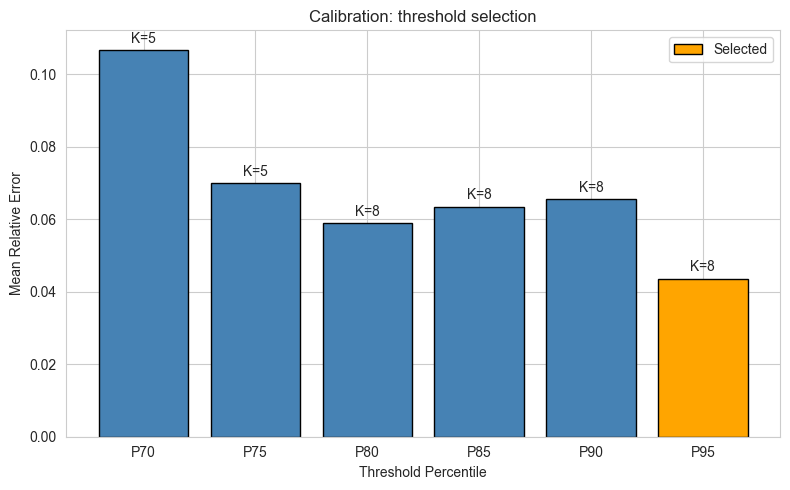

In [10]:
# VISUALIZE CALIBRATION RESULTS 

# Plots
fig, ax = plt.subplots(figsize=(8, 5))
all_res = threshold_result["all_results"]
labels = [f"P{r['percentile']}" for r in all_res]
errs   = [r["mean_rel_error"]   for r in all_res]
bars   = ax.bar(labels, errs, color="steelblue", edgecolor="black")

K_labels = [f"K={r['K']}" for r in all_res]
ax.bar_label(bars, labels=K_labels, padding=3)

best_idx = labels.index(f"P{best_bt['percentile']}")
bars[best_idx].set_facecolor("orange")

ax.set_ylabel("Mean Relative Error")
ax.set_xlabel("Threshold Percentile")
ax.set_title("Calibration: threshold selection")
ax.legend(handles=[bars[best_idx]], labels=["Selected"])
plt.tight_layout()
plt.show()

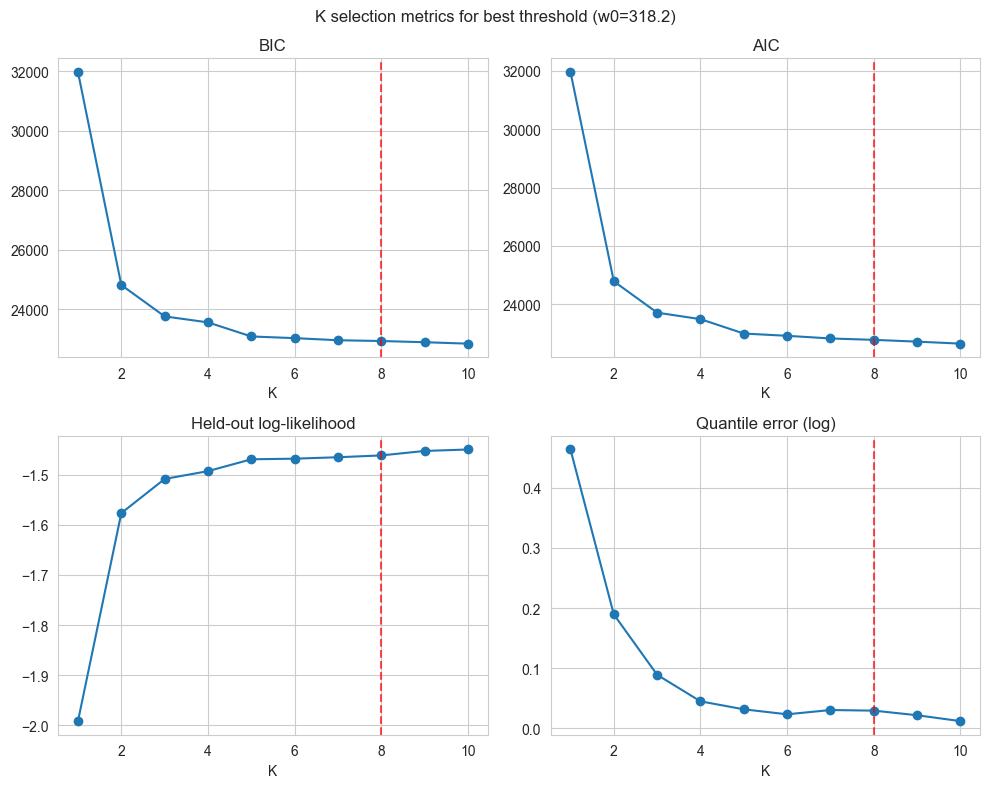

In [11]:
# VISUALIZE K-SELECTION METRICS FOR BEST THRESHOLD

k_result = select_optimal_K(weights_real, best_bt["w0"], rng=rng, return_metrics=True)
K_vals = k_result["K_candidates"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].plot(K_vals, k_result["bic"], "o-")
axes[0, 0].set_title("BIC")
axes[0, 0].set_xlabel("K")
axes[0, 0].axvline(best_bt["K"], color="r", ls="--", alpha=0.7, label=f"Selected K={best_bt['K']}")

axes[0, 1].plot(K_vals, k_result["aic"], "o-")
axes[0, 1].set_title("AIC")
axes[0, 1].set_xlabel("K")
axes[0, 1].axvline(best_bt["K"], color="r", ls="--", alpha=0.7)

axes[1, 0].plot(K_vals, k_result["heldout_ll"], "o-")
axes[1, 0].set_title("Held-out log-likelihood")
axes[1, 0].set_xlabel("K")
axes[1, 0].axvline(best_bt["K"], color="r", ls="--", alpha=0.7)

axes[1, 1].plot(K_vals, k_result["quant_errs"], "o-")
axes[1, 1].set_title("Quantile error (log)")
axes[1, 1].set_xlabel("K")
axes[1, 1].axvline(best_bt["K"], color="r", ls="--", alpha=0.7)

fig.suptitle(f"K selection metrics for best threshold (w0={best_bt['w0']:.1f})", fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
# LOCK CALIBRATED PARAMETERS
# Note: if you want to override the automatic selection, 
# edit SELECTED_K_BT and SELECTED_PERCENTILE and re-run from this cell

# Extract best K and best percentile 
SELECTED_K_BT    = best_bt["K"]
SELECTED_PERCENTILE = best_bt["percentile"]

# Compute best threshold and p_tail
w0     = np.percentile(weights_real, SELECTED_PERCENTILE)
p_tail = (weights_real > w0).mean()

# Fit body-tal using best K and best threshold
body_params = fit_lognormal_mixture_body(weights_real, w0, n_components=SELECTED_K_BT)
tail_params = fit_gpd_tail(weights_real, w0)

## 5. Inspect Calibrated Models

### 5.1 Body model

We sample from the calibrated body mixture and compare to the real body
weights ($w \leq w_0$) on both log and original scales.

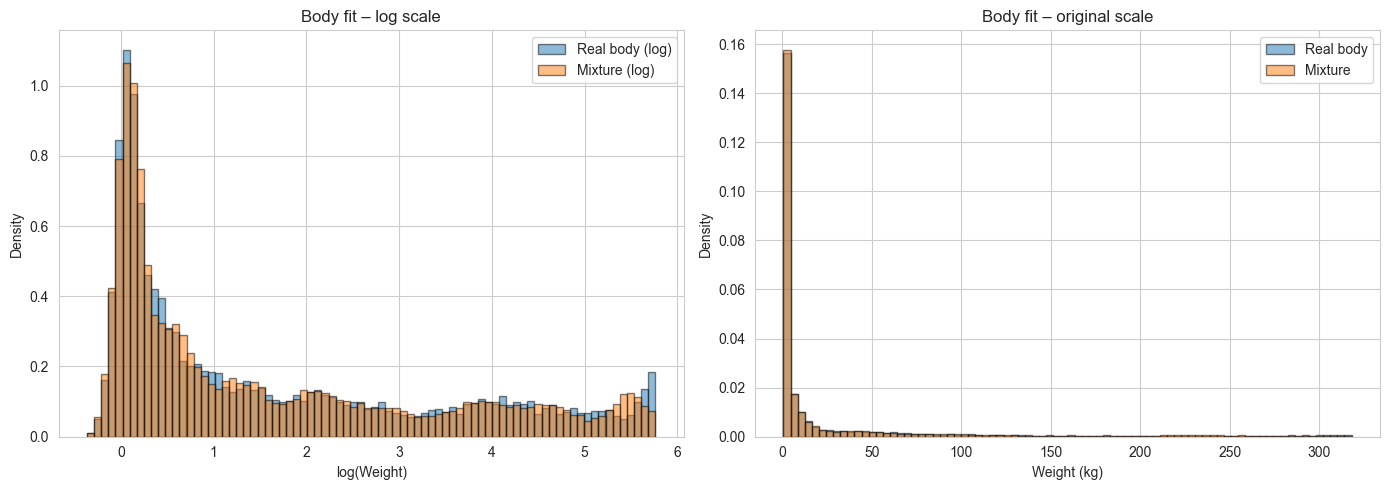

Body mixture (K=8, w0=318.15):
  Component 1: pi=0.3492, mu=0.0824, sigma=0.1347
  Component 8: pi=0.1736, mu=0.5436, sigma=0.2216
  Component 5: pi=0.1138, mu=1.2508, sigma=0.2863
  Component 3: pi=0.0879, mu=2.0789, sigma=0.2917
  Component 6: pi=0.0659, mu=2.8482, sigma=0.3355
  Component 2: pi=0.0812, mu=3.8324, sigma=0.3293
  Component 7: pi=0.0701, mu=4.6310, sigma=0.3284
  Component 4: pi=0.0583, mu=5.4922, sigma=0.2210


In [16]:
# SAMPLE K-COMPONENT LOGNORMAL MIXTURE

# Filter values below the threshold
body_real = weights_real[weights_real <= w0]

# Sample the fitted log-normal mixture body
body_samples = sample_truncated_lognormal_mixture(
    body_params["mix_weights"], body_params["means"], body_params["stds"],
    body_params["w_min"], body_params["w0"],
    size=50_000, rng=rng,
)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log(body_real), bins=80, density=True, alpha=0.5,
             label="Real body (log)", edgecolor="black")
axes[0].hist(np.log(body_samples), bins=80, density=True, alpha=0.5,
             label="Mixture (log)", edgecolor="black")
axes[0].set_xlabel("log(Weight)")
axes[0].set_ylabel("Density")
axes[0].set_title("Body fit – log scale")
axes[0].legend()

axes[1].hist(body_real, bins=80, density=True, alpha=0.5,
             label="Real body", edgecolor="black")
axes[1].hist(body_samples, bins=80, density=True, alpha=0.5,
             label="Mixture", edgecolor="black")
axes[1].set_xlabel("Weight (kg)")
axes[1].set_ylabel("Density")
axes[1].set_title("Body fit – original scale")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print results
print(f"Body mixture (K={body_params['n_components']}, w0={w0:.2f}):")
order = np.argsort(body_params["means"])
for k in order:
    print(f"  Component {k+1}: pi={body_params['mix_weights'][k]:.4f}, "
          f"mu={body_params['means'][k]:.4f}, sigma={body_params['stds'][k]:.4f}")

### 5.2 Tail model

We sample from the fitted GPD tail distribution and compare to the real body
weights ($w \gt w_0$).

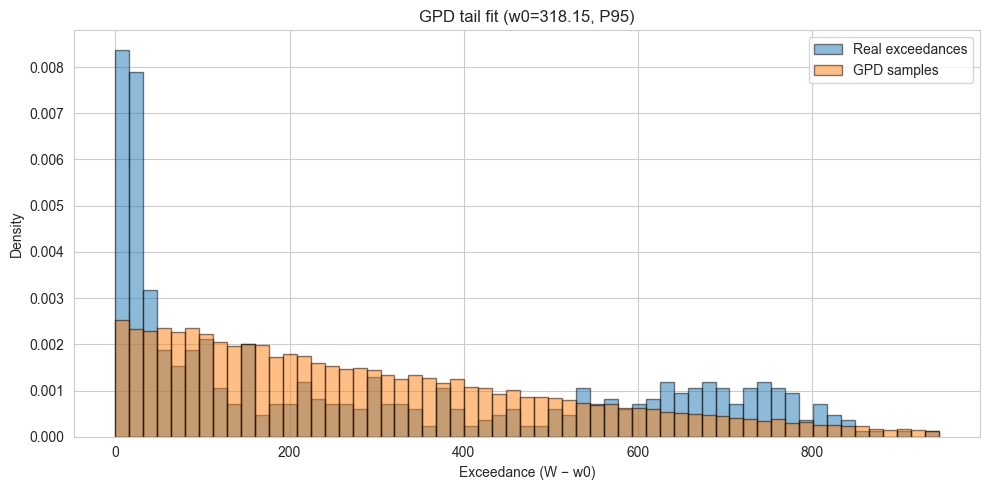

GPD fit on exceedances above w0=318.15:
  xi  (shape) = -0.3172
  beta (scale) = 395.4219
  Tail size:  529
  Exceedance range: [0, 945.59]


In [17]:
# SAMPLE GPD

# Filter values above the threshold
exc_real  = weights_real[weights_real > w0] - w0

# Compute exceedances
exc_upper = tail_params["w_max"] - w0

# the fitted GPD
exc_samples = sample_truncated_gpd(
    tail_params["xi"], tail_params["beta"], exc_upper,
    size=50_000, rng=rng,
)

# Plots
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, exc_upper, 60)
ax.hist(exc_real,    bins=bins, density=True, alpha=0.5,
        label="Real exceedances", edgecolor="black")
ax.hist(exc_samples, bins=bins, density=True, alpha=0.5,
        label="GPD samples", edgecolor="black")
ax.set_xlabel("Exceedance (W − w0)")
ax.set_ylabel("Density")
ax.set_title(f"GPD tail fit (w0={w0:.2f}, P{SELECTED_PERCENTILE})")
ax.legend()
plt.tight_layout()
plt.show()


# Print results
print(f"GPD fit on exceedances above w0={w0:.2f}:")
print(f"  xi  (shape) = {tail_params['xi']:.4f}")
print(f"  beta (scale) = {tail_params['beta']:.4f}")
print(f"  Tail size:  {(weights_real > w0).sum():,}")
print(f"  Exceedance range: [0, {exc_upper:.2f}]")

## 6. Combined Sampling

We combine body and tail into two sampling modes. Both use the same fitted models (truncated log-normal mixture for the body ($W \leq w_0$) and truncated GPD for the tail ($W > w_0$)), but differ in how the body–tail split is determined.


| Mode | How it works | Use case |
|------|-------------|----------|
| **Unconditional** | Each SKU draws body vs. tail via $\text{Bernoulli}(p_{\text{tail}})$ | General-purpose synthetic weights |
| **Stress-test** | Exactly $k = \text{round}(p_{\text{tail}} \cdot N)$ SKUs forced to tail | Worst-case loading scenarios |

### Sampling mode details

- **Unconditional** (`sample_weights_unconditional`): Each of the $N$ SKUs independently draws from the body with probability $1 - p_{\text{tail}}$ and from the tail with probability $p_{\text{tail}}$. The number of tail SKUs is therefore random (Binomial) and reproduces the empirical tail proportion on average. Use this for realistic synthetic datasets that match the real distribution.

- **Stress-test** (`sample_weights_stress_test`): Exactly $k = \text{round}(p_{\text{tail}} \cdot N)$ SKUs are sampled from the tail, and the remaining $N - k$ from the body. The tail count is fixed, not random. Use this to stress-test systems under the maximum plausible number of heavy items (e.g. warehouse capacity, vehicle loading).

In [18]:
# UNCONDITIONAL AND STRESS-TEST SAMPLING

# Define a test sample size
n_demo = 10_000

# Sample using both modes
w_uncond = sample_weights_unconditional(n_demo, body_params, tail_params, p_tail, rng)
w_stress = sample_weights_stress_test(n_demo, body_params, tail_params, p_tail, rng)

# Print results
for label, arr in [("REAL", weights_real),
                   ("UNCONDITIONAL", w_uncond),
                   ("STRESS-TEST", w_stress)]:
    print("-"*55)
    print(f"{label} (n={len(arr):,}):")
    print("-"*55)
    print(f"Mean={arr.mean():.2f}  Median={np.median(arr):.2f}  "
          f"Std={arr.std():.2f}  Min={arr.min():.2f}  Max={arr.max():.2f}\n")

-------------------------------------------------------
REAL (n=10,578):
-------------------------------------------------------
Mean=58.01  Median=2.49  Std=153.88  Min=0.69  Max=1263.75

-------------------------------------------------------
UNCONDITIONAL (n=10,000):
-------------------------------------------------------
Mean=56.83  Median=2.48  Std=145.22  Min=0.70  Max=1244.82

-------------------------------------------------------
STRESS-TEST (n=10,000):
-------------------------------------------------------
Mean=56.59  Median=2.44  Std=142.64  Min=0.71  Max=1253.99



## 7. Alternative: Full-Data Log-Normal Mixture

As a simpler alternative  to the body–tail decomposition we fit a log-normal mixture to the entire
distribution (no body–tail split).  $K$-selection follows the same procedure used in the
calibration sweep, but applied to all weights. Using the selected $K$, we fit the log-normal mixture to all $w$ in log-space and then sample from its PDF via truncated mixture sampling on $[w_{\min}, w_{\max}]$.

$$f_{\text{full}}(\log w) = \sum_{k=1}^{K} \pi_k \,\mathcal{N}(\log w \mid \mu_k, \sigma_k^2), \quad w_{\min} \leq w \leq w_{\max}$$

We again use the inverse-CDF approach for sampling. 

In [19]:
# K-SELECTION

# Auto-select K for the full mixture
w0_full = weights_real.max()
full_K_result = select_optimal_K(weights_real, w0_full, rng=rng)
SELECTED_K_FULL = full_K_result["selected_K"]

# Print results
print(f"Selected K for full-data mixture: {SELECTED_K_FULL}")

Selected K for full-data mixture: 8


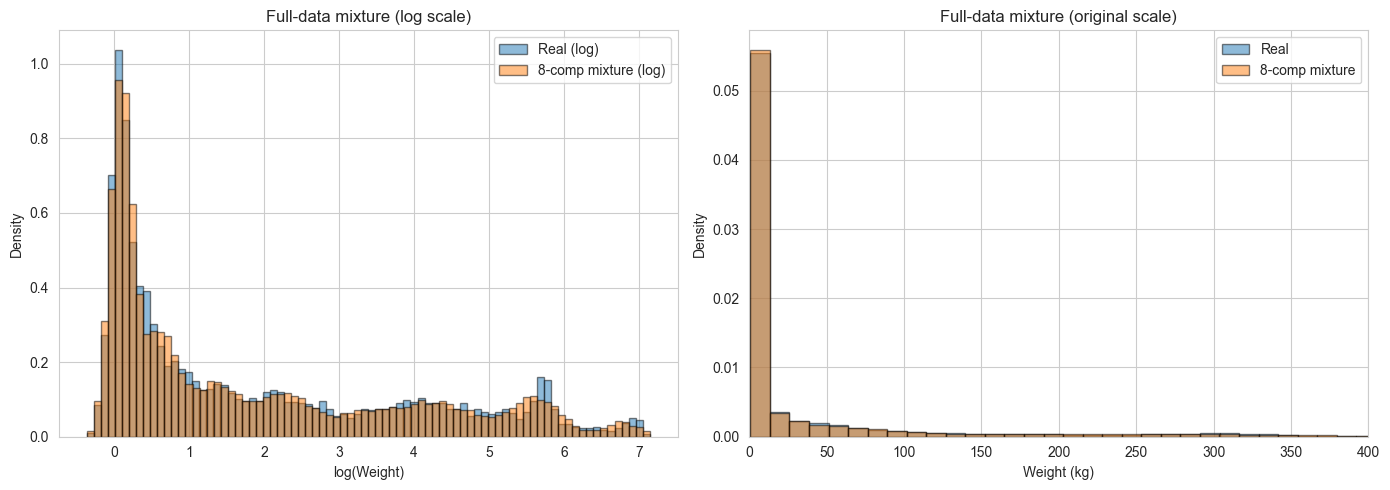

In [20]:
# FIT AND SAMPLE THE FULL MIXTURE

# Fit the full-data mixture
log_all = np.log(weights_real[weights_real > 0]).reshape(-1, 1)
gm_full = GaussianMixture(
    n_components=SELECTED_K_FULL, random_state=42,
    n_init=10, max_iter=500, reg_covar=1e-6,
)
gm_full.fit(log_all)

# Store fitted parameters
full_mix_params = {
    "mix_weights": gm_full.weights_,
    "means": gm_full.means_.flatten(),
    "stds": np.sqrt(gm_full.covariances_.flatten()),
    "n_components": SELECTED_K_FULL,
    "w_min": weights_real.min(),
    "w_max": weights_real.max(),
}

# Sample and compare the full-data mixture
full_mix_samples = sample_truncated_lognormal_mixture(
    full_mix_params["mix_weights"], full_mix_params["means"],
    full_mix_params["stds"], full_mix_params["w_min"], full_mix_params["w_max"],
    size=50_000, rng=rng,
)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log(weights_real), bins=80, density=True, alpha=0.5,
             label="Real (log)", edgecolor="black")
axes[0].hist(np.log(full_mix_samples), bins=80, density=True, alpha=0.5,
             label=f"{SELECTED_K_FULL}-comp mixture (log)", edgecolor="black")
axes[0].set_xlabel("log(Weight)")
axes[0].set_ylabel("Density")
axes[0].set_title("Full-data mixture (log scale)")
axes[0].legend()

axes[1].hist(weights_real, bins=100, density=True, alpha=0.5,
             label="Real", edgecolor="black")
axes[1].hist(full_mix_samples, bins=100, density=True, alpha=0.5,
             label=f"{SELECTED_K_FULL}-comp mixture", edgecolor="black")
axes[1].set_xlabel("Weight (kg)")
axes[1].set_ylabel("Density")
axes[1].set_title("Full-data mixture (original scale)")
axes[1].legend()
axes[1].set_xlim(0, 400)

plt.tight_layout()
plt.show()

In [21]:
# SAVE FITTED MODEL

# Create path
MODELS_PATH = Path("outputs/generated_models")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# Save gm_full + full_mix_params for production truncated sampling
weight_model = {
    "gm_full": gm_full,
    "full_mix_params": full_mix_params,
}
with open(MODELS_PATH / "weight_gmm.pkl", "wb") as f:
    pickle.dump(weight_model, f)
print(f"Saved weight_gmm.pkl to {MODELS_PATH}/")

Saved weight_gmm.pkl to outputs\generated_models/


## 8. Final Calibrated Parameters

We extract the calibrated parameters for the selected threshold $w_0$ and store them for reuse. For comparison, we also store the fitted full log-normal mixture parameters.

In [22]:
# HELPERS

def _sort_params(params: dict) -> dict:
    """Sort mixture components by mean."""
    order = np.argsort(params["means"])
    return {
        **params,
        "mix_weights": np.array(params["mix_weights"])[order],
        "means": np.array(params["means"])[order],
        "stds": np.array(params["stds"])[order],
    }

In [23]:
# FINAL CALIBRATED PARAMETERS

# Sort components by mean
body_sorted = _sort_params(body_params)
full_sorted = _sort_params(full_mix_params)

# Print results
print("=" * 55)
print("  CALIBRATED PARAMETERS — BODY-TAIL MODEL")
print("=" * 55)
print(f"  Threshold (w0):   {w0:.4f}  (P{SELECTED_PERCENTILE})")
print(f"  Tail probability: {p_tail:.6f}")
print(f"  Weight range:     [{body_params['w_min']:.4f}, {tail_params['w_max']:.4f}]")
print(f"\n  Body (log-normal mixture, K={body_params['n_components']}):")
for k in range(body_sorted["n_components"]):
    print(f"    Component {k+1}: pi={body_sorted['mix_weights'][k]:.4f}, "
          f"mu={body_sorted['means'][k]:.4f}, sigma={body_sorted['stds'][k]:.4f}")
print(f"\n  Tail (GPD exceedances):")
print(f"    xi   (shape) = {tail_params['xi']:.6f}")
print(f"    beta (scale) = {tail_params['beta']:.6f}")

print()
print("=" * 55)
print("  CALIBRATED PARAMETERS — FULL MIXTURE MODEL")
print("=" * 55)
print(f"  Weight range: [{full_mix_params['w_min']:.4f}, {full_mix_params['w_max']:.4f}]")
print(f"\n  Full mixture (K={full_mix_params['n_components']}):")
for k in range(full_sorted["n_components"]):
    print(f"    Component {k+1}: pi={full_sorted['mix_weights'][k]:.4f}, "
          f"mu={full_sorted['means'][k]:.4f}, sigma={full_sorted['stds'][k]:.4f}")
print("=" * 55)

  CALIBRATED PARAMETERS — BODY-TAIL MODEL
  Threshold (w0):   318.1519  (P95)
  Tail probability: 0.050009
  Weight range:     [0.6947, 1263.7453]

  Body (log-normal mixture, K=8):
    Component 1: pi=0.3492, mu=0.0824, sigma=0.1347
    Component 2: pi=0.1736, mu=0.5436, sigma=0.2216
    Component 3: pi=0.1138, mu=1.2508, sigma=0.2863
    Component 4: pi=0.0879, mu=2.0789, sigma=0.2917
    Component 5: pi=0.0659, mu=2.8482, sigma=0.3355
    Component 6: pi=0.0812, mu=3.8324, sigma=0.3293
    Component 7: pi=0.0701, mu=4.6310, sigma=0.3284
    Component 8: pi=0.0583, mu=5.4922, sigma=0.2210

  Tail (GPD exceedances):
    xi   (shape) = -0.317244
    beta (scale) = 395.421869

  CALIBRATED PARAMETERS — FULL MIXTURE MODEL
  Weight range: [0.6947, 1263.7453]

  Full mixture (K=8):
    Component 1: pi=0.3379, mu=0.0884, sigma=0.1395
    Component 2: pi=0.1742, mu=0.5853, sigma=0.2498
    Component 3: pi=0.1033, mu=1.3536, sigma=0.3076
    Component 4: pi=0.1045, mu=2.2798, sigma=0.3711
   

## 9. Testing & Validation

We systematically test both models against the real data with summary
statistics, visual diagnostics, formal statistical tests, and scalability
analysis.

In [25]:
# SAMPLE TEST WEIGHTS FROM BODY-TAIL AND FULL-MIXTURE

# Set number of samples and rng for tests
n_test = N_TEST_SKUS or len(weights_real)
rng_test = rng

# Draw n_test samples from the body-tail distribution (unconditional)
w_bt = sample_weights_unconditional(
    n_test, body_params, tail_params, p_tail, rng_test,
)

# Draw n_test samples from the full-mixture distribution
w_full = sample_truncated_lognormal_mixture(
    full_mix_params["mix_weights"], full_mix_params["means"],
    full_mix_params["stds"], full_mix_params["w_min"], full_mix_params["w_max"],
    size=n_test, rng=rng_test,
)

# Print results
print(f"Generated {n_test:,} weights from each model.")

Generated 10,578 weights from each model.


### 9.1 Summary Statistics Comparison

Compare mean, median, std, skewness, kurtosis, and key percentiles between the real data and the two fitted models. The relative error column shows $\frac{|x_{\text{real}} - x_{\text{gen}}|}{|x_{\text{real}}|}$ for each statistic.

In [26]:
# SUMMARY STATISTICS COMPARISON

# Compute summary stats
real_s = compute_summary_stats(weights_real)
bt_s   = compute_summary_stats(w_bt)
full_s = compute_summary_stats(w_full)

# Print results
print("-"*55)
print("Summary Statistic Comparison")
print("-"*55)
print(f"{'Stat':>10}  {'Real':>10}  {'Body-Tail':>10}  {'Full-Mix':>10}"
      f"  {'RelErr BT':>10}  {'RelErr FM':>10}")
for key in real_s:
    r = real_s[key]
    b = bt_s[key]
    f = full_s[key]
    re_bt = abs(r - b) / max(abs(r), 1e-9)
    re_fm = abs(r - f) / max(abs(r), 1e-9)
    print(f"{key:>10}  {r:10.4f}  {b:10.4f}  {f:10.4f}"
          f"  {re_bt:10.4f}  {re_fm:10.4f}")

print("\n"+("-"*55))
print("Mean Relative Error")
print("-"*55)
print(f"    Mean RE  Body–Tail: {relative_error(real_s, bt_s):.4f}")
print(f"    Mean RE  Full Mix:  {relative_error(real_s, full_s):.4f}")

-------------------------------------------------------
Summary Statistic Comparison
-------------------------------------------------------
      Stat        Real   Body-Tail    Full-Mix   RelErr BT   RelErr FM
      mean     58.0137     59.6338     57.2966      0.0279      0.0124
    median      2.4891      2.5581      2.4355      0.0277      0.0215
       std    153.8762    156.5351    152.5677      0.0173      0.0085
      skew      4.3271      4.0359      4.2858      0.0673      0.0095
  kurtosis     21.5347     18.3377     21.1735      0.1485      0.0168
       p25      1.1741      1.1795      1.1821      0.0047      0.0069
       p75     27.7156     25.2301     25.3116      0.0897      0.0867
       p90    180.9090    192.1385    185.4196      0.0621      0.0249
       p95    318.1519    338.6643    322.7081      0.0645      0.0143
       p99    947.1616    850.2646    882.3379      0.1023      0.0684
       max   1263.7453   1250.6057   1263.1378      0.0104      0.0005

------

### 9.2 Visual Comparison

Three diagnostics per model:

1. **Histogram overlay** on the original scale (clipped to P99 for readability).
2. **Log-scale histogram** to reveal the full distributional shape.
3. **QQ-plot** against the real data.

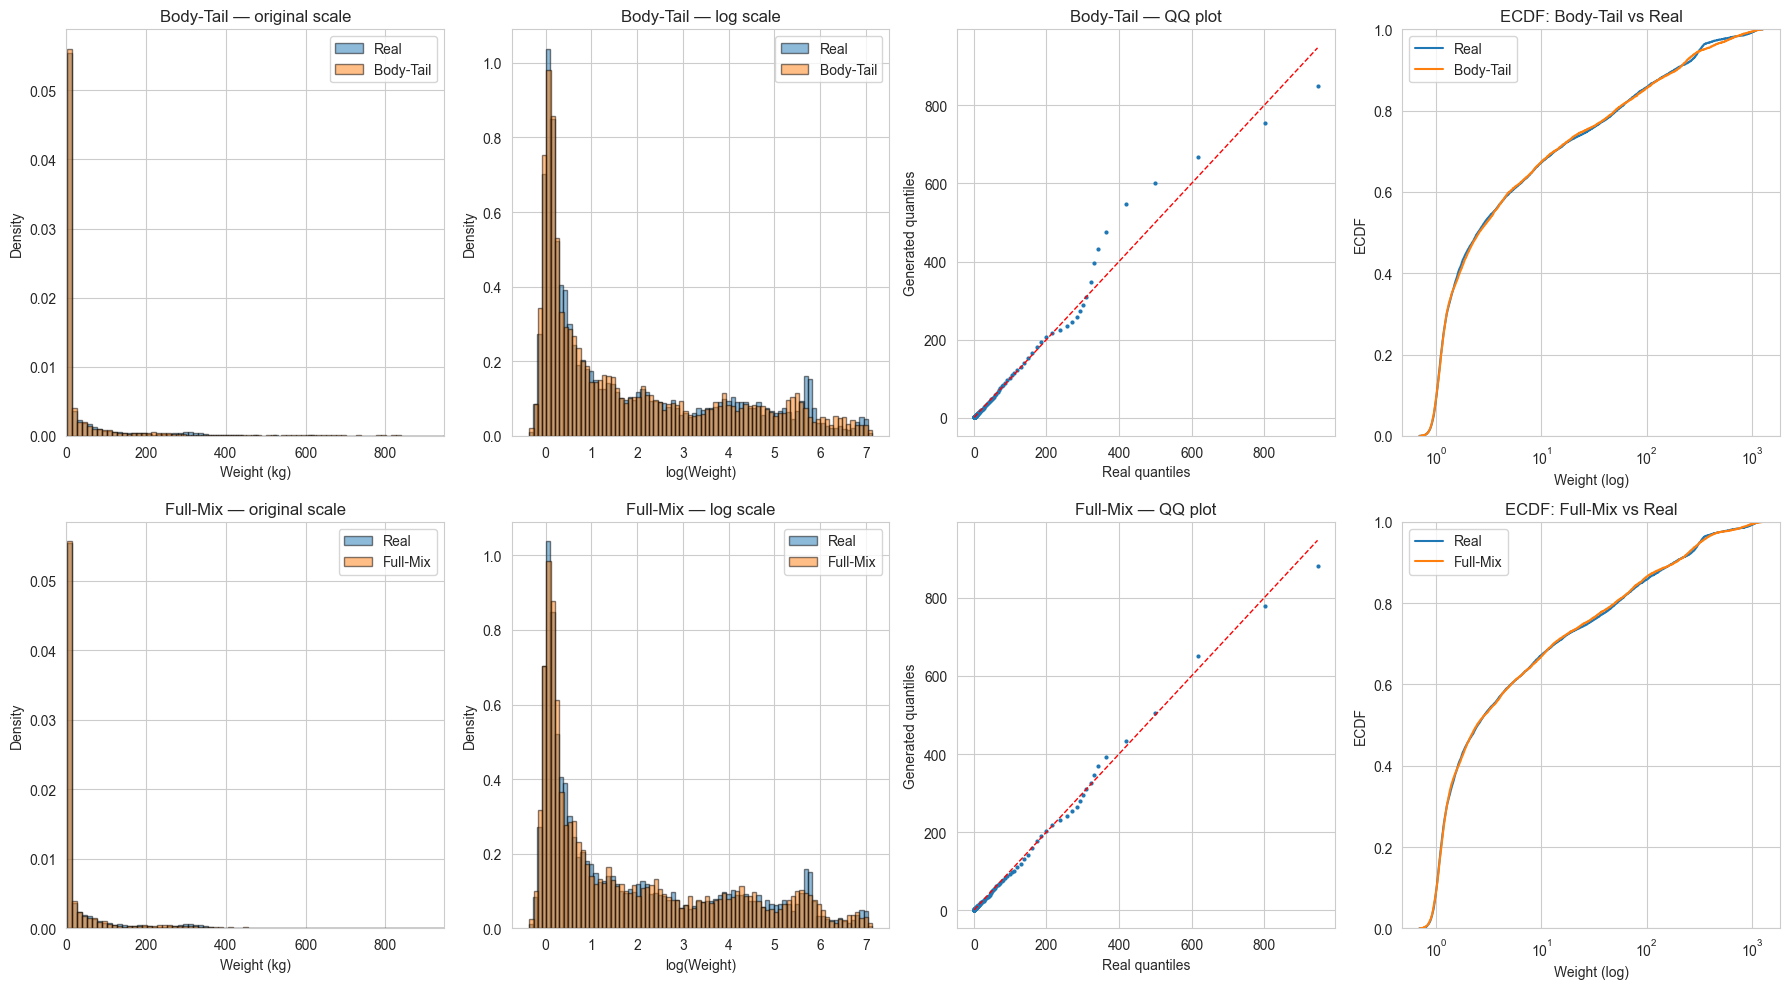

In [28]:
# VISUAL COMPARISON

# Plots
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

clip = np.percentile(weights_real, 99)

for row, (label, w_gen) in enumerate([("Body-Tail", w_bt), ("Full-Mix", w_full)]):
    
    # Original-scale histogram
    axes[row, 0].hist(weights_real, bins=100, density=True, alpha=0.5,
                      label="Real", edgecolor="black")
    axes[row, 0].hist(w_gen, bins=100, density=True, alpha=0.5,
                      label=label, edgecolor="black")
    axes[row, 0].set_xlim(0, clip)
    axes[row, 0].set_xlabel("Weight (kg)")
    axes[row, 0].set_ylabel("Density")
    axes[row, 0].set_title(f"{label} — original scale")
    axes[row, 0].legend()

    # Log-scale histogram
    axes[row, 1].hist(np.log(weights_real), bins=80, density=True, alpha=0.5,
                      label="Real", edgecolor="black")
    axes[row, 1].hist(np.log(w_gen), bins=80, density=True, alpha=0.5,
                      label=label, edgecolor="black")
    axes[row, 1].set_xlabel("log(Weight)")
    axes[row, 1].set_ylabel("Density")
    axes[row, 1].set_title(f"{label} — log scale")
    axes[row, 1].legend()

    # QQ-plot
    q_grid = np.linspace(0.01, 0.99, 200)
    q_real = np.quantile(weights_real, q_grid)
    q_gen  = np.quantile(w_gen, q_grid)
    axes[row, 2].plot(q_real, q_gen, "o", markersize=2)
    lo = min(q_real.min(), q_gen.min())
    hi = max(q_real.max(), q_gen.max())
    axes[row, 2].plot([lo, hi], [lo, hi], "r--", linewidth=1)
    axes[row, 2].set_xlabel("Real quantiles")
    axes[row, 2].set_ylabel("Generated quantiles")
    axes[row, 2].set_title(f"{label} — QQ plot")

    # ECDFs
    axes[row, 3].ecdf(weights_real, label="Real")
    axes[row, 3].ecdf(w_gen, label=label)
    axes[row, 3].set_xscale("log")
    axes[row, 3].set_xlabel("Weight (log)")
    axes[row, 3].set_ylabel("ECDF")
    axes[row, 3].set_title(f"ECDF: {label} vs Real")
    axes[row, 3].legend()

plt.tight_layout()
plt.show()

### 9.3 Statistical Tests

We apply two-sample tests comparing the generated samples to the real data:

| Test | Null hypothesis |
|------|----------------|
| **Kolmogorov–Smirnov** | The two samples come from the same distribution |
| **Anderson–Darling (k-sample)** | The samples come from a common unspecified distribution |
| **Cramér–von Mises** | The two samples come from the same distribution |

A small p-value (or large test statistic) indicates a significant difference between generated and real weights. Note that with large sample sizes, most tests will reject. However, what matters is the *magnitude* of the test statistic relative to the other model (the smaller the better).

In [29]:
# STATISTICAL TESTS

# Perform tests and print results
print("-"*55)
print("Statistical Tests Results")
print("-"*55)
for label, w_gen in [("Body-Tail", w_bt), ("Full-Mix", w_full)]:
    ks_stat, ks_p = stats.ks_2samp(weights_real, w_gen)
    ad_stat, _, ad_p = stats.anderson_ksamp([weights_real, w_gen])
    cvm = stats.cramervonmises_2samp(weights_real, w_gen)
    print(f"{label}:")
    print(f"  KS statistic = {ks_stat:.4f},  p-value = {ks_p:.4e}")
    print(f"  AD statistic = {ad_stat:.4f},  p-value = {ad_p:.4e}")
    print(f"  CvM statistic = {cvm.statistic:.4f},  p-value = {cvm.pvalue:.4e}\n")

-------------------------------------------------------
Statistical Tests Results
-------------------------------------------------------
Body-Tail:
  KS statistic = 0.0134,  p-value = 2.9369e-01
  AD statistic = 0.1354,  p-value = 2.5000e-01
  CvM statistic = 0.1221,  p-value = 4.8712e-01

Full-Mix:
  KS statistic = 0.0096,  p-value = 7.0533e-01
  AD statistic = -0.4255,  p-value = 2.5000e-01
  CvM statistic = 0.0850,  p-value = 6.6337e-01



### 9.4 Scalability & Stability

We sweep sample sizes and repeat each size with different seeds to measure
how summary-statistic errors behave as we vary $N$.

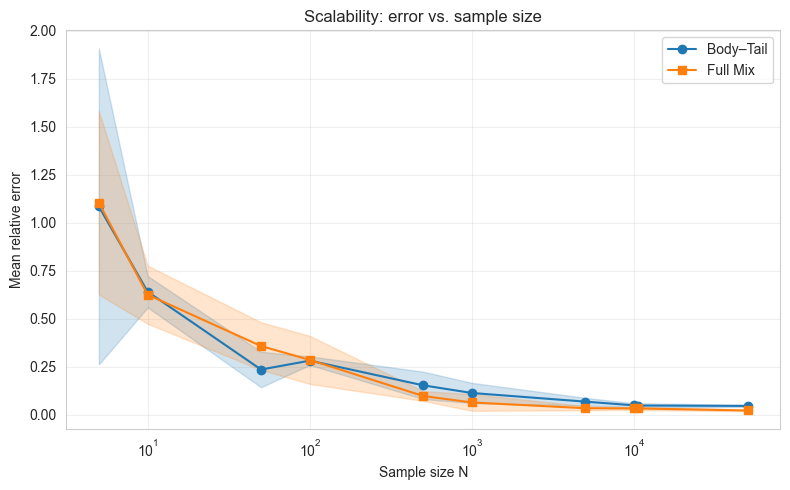

In [30]:
# SCALABILITY AND STABILITY TO DIFFERENT SAMPLE SIZES

# Set parameters
sample_sizes = [5, 10, 50, 100, 500, 1_000, 5_000, 10_000, 50_000, len(weights_real)]
n_repeats = 5

# Draw from the body-tail and full-mixture for all sample sizes
scalability = []
for n in sample_sizes:
    for seed in range(n_repeats):
        rng_s  = np.random.default_rng(seed + 2000)
        rng_s2 = np.random.default_rng(seed + 1000)

        w_bt_s = sample_weights_unconditional(
            n, body_params, tail_params, p_tail, rng_s,
        )
        w_full_s = sample_truncated_lognormal_mixture(
            full_mix_params["mix_weights"], full_mix_params["means"],
            full_mix_params["stds"], full_mix_params["w_min"], full_mix_params["w_max"],
            size=n, rng=rng_s2,
        )

        scalability.append({
            "n": n, "seed": seed,
            "bt_err":   relative_error(real_s, compute_summary_stats(w_bt_s)),
            "full_err": relative_error(real_s, compute_summary_stats(w_full_s)),
        })

# Create a results dataframe
import pandas as pd
df = pd.DataFrame(scalability)
g = df.groupby("n")[["bt_err", "full_err"]]
mean = g.mean()
std  = g.std()
ns   = mean.index.values
bt_m = mean["bt_err"].values
bt_s = std["bt_err"].values
fm_m = mean["full_err"].values
fm_s = std["full_err"].values


# Plots
fig, ax = plt.subplots(figsize=(8, 5))
# Body–Tail
ax.plot(ns, bt_m, "o-", label="Body–Tail", color="tab:blue")
ax.fill_between(ns, bt_m - bt_s, bt_m + bt_s, alpha=0.2, color="tab:blue")

# Full Mix
ax.plot(ns, fm_m, "s-", label="Full Mix", color="tab:orange")
ax.fill_between(ns, fm_m - fm_s, fm_m + fm_s, alpha=0.2, color="tab:orange")

ax.set_xscale("log")
ax.set_xlabel("Sample size N")
ax.set_ylabel("Mean relative error")
ax.set_title("Scalability: error vs. sample size")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.5 Heavy-Item Counts (Threshold Crossing)

For practical supply-chain use, we want the generated data to reproduce the fraction of "heavy" items whose weight exceeds a given threshold. We compare the expected vs. observed count of weights above several thresholds for different sample sizes.

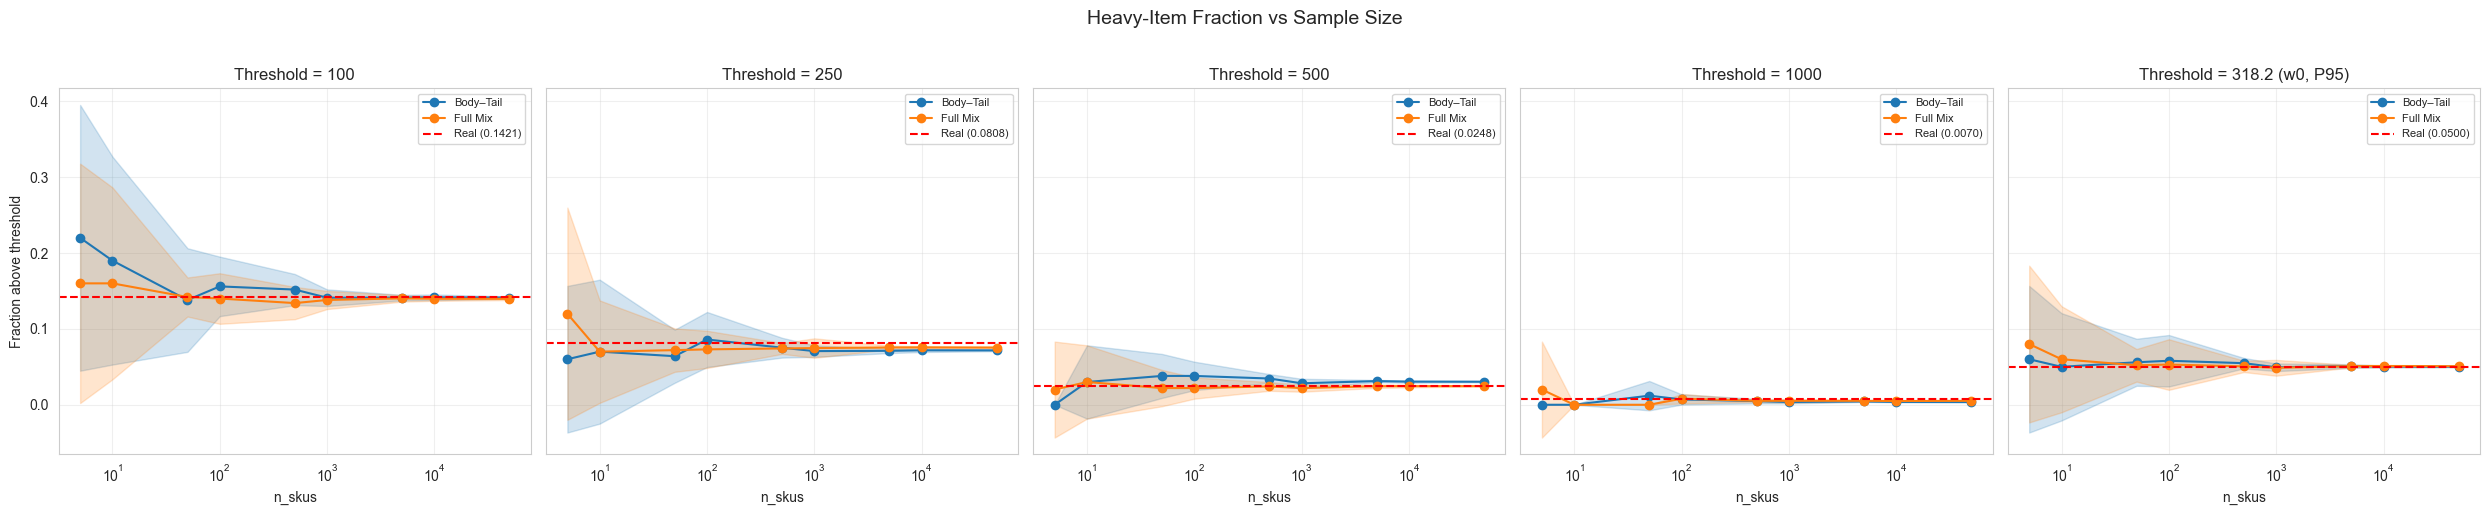

=== Heavy-item counts (mean over seeds) ===

Threshold = 100  |  Real fraction: 0.142087
  Body–Tail     n=5: 0.220  n=10: 0.190  n=50: 0.138  n=100: 0.156  n=500: 0.152  n=1000: 0.141  n=5000: 0.141  n=10000: 0.142  n=50000: 0.141
  Full Mix      n=5: 0.160  n=10: 0.160  n=50: 0.142  n=100: 0.140  n=500: 0.134  n=1000: 0.138  n=5000: 0.140  n=10000: 0.140  n=50000: 0.140

Threshold = 250  |  Real fraction: 0.080828
  Body–Tail     n=5: 0.060  n=10: 0.070  n=50: 0.064  n=100: 0.086  n=500: 0.075  n=1000: 0.071  n=5000: 0.071  n=10000: 0.072  n=50000: 0.072
  Full Mix      n=5: 0.120  n=10: 0.070  n=50: 0.072  n=100: 0.073  n=500: 0.074  n=1000: 0.075  n=5000: 0.075  n=10000: 0.076  n=50000: 0.075

Threshold = 500  |  Real fraction: 0.024768
  Body–Tail     n=5: 0.000  n=10: 0.030  n=50: 0.038  n=100: 0.038  n=500: 0.035  n=1000: 0.028  n=5000: 0.031  n=10000: 0.030  n=50000: 0.030
  Full Mix      n=5: 0.020  n=10: 0.030  n=50: 0.022  n=100: 0.022  n=500: 0.024  n=1000: 0.022  n=5000: 0

In [31]:
# HEAVY ITEM COUNT 

# Set parameters
thresholds = [100, 250, 500, 1000, w0]
heavy_sizes = [5, 10, 50, 100, 500, 1_000, 5_000, 10_000, 50_000]
n_heavy_repeats = 10

# Compute the fraction of items above all specified thresholds for the real data
real_fracs = {thr: (weights_real > thr).mean() for thr in thresholds}

# Compute the fraction of items above all specified tresholds
heavy_records = []
for thr in thresholds:
    real_frac = (weights_real > thr).mean()
    for n in heavy_sizes:
        bt_fracs, full_fracs = [], []
        for seed in range(n_heavy_repeats):
            rng_h  = np.random.default_rng(seed + 4000)
            rng_h2 = np.random.default_rng(seed + 3000)

            wb = sample_weights_unconditional(n, body_params, tail_params, p_tail, rng_h)
            wf = sample_truncated_lognormal_mixture(
                full_mix_params["mix_weights"], full_mix_params["means"],
                full_mix_params["stds"], full_mix_params["w_min"],
                full_mix_params["w_max"], size=n, rng=rng_h2,
            )
            bt_frac = (wb > thr).mean()
            full_frac = (wf > thr).mean()
            bt_fracs.append(bt_frac)
            full_fracs.append(full_frac)
            heavy_records.append({
                "n": n, "seed": seed, "threshold": thr,
                "model": "Body–Tail",
                "count_above": np.sum(wb > thr),
                "frac_above": bt_frac,
            })
            heavy_records.append({
                "n": n, "seed": seed, "threshold": thr,
                "model": "Full Mix",
                "count_above": np.sum(wf > thr),
                "frac_above": full_frac,
            })
df_heavy = pd.DataFrame(heavy_records)

# Plots
fig, axes = plt.subplots(1, len(thresholds), figsize=(5 * len(thresholds), 5), sharey=True)
for i, t in enumerate(thresholds):
    ax = axes[i]
    sub = df_heavy[df_heavy["threshold"] == t]
    for model, color in [("Body–Tail", "tab:blue"), ("Full Mix", "tab:orange")]:
        m = sub[sub["model"] == model]
        grouped = m.groupby("n")["frac_above"]
        ns = grouped.mean().index
        means = grouped.mean().values
        stds  = grouped.std().values
        ax.plot(ns, means, "o-", label=model, color=color)
        ax.fill_between(ns, means - stds, means + stds, alpha=0.2, color=color)
    ax.axhline(real_fracs[t], color="red", ls="--", lw=1.5, label=f"Real ({real_fracs[t]:.4f})")
    t_label = f"{t:.1f} (w0, P{SELECTED_PERCENTILE:d})" if t == w0 else f"{t:.0f}"
    ax.set_title(f"Threshold = {t_label}")
    ax.set_xscale("log")
    ax.set_xlabel("n_skus")
    if i == 0:
        ax.set_ylabel("Fraction above threshold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Heavy-Item Fraction vs Sample Size", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print results
print("=== Heavy-item counts (mean over seeds) ===\n")
for t in thresholds:
    t_label = f"w0={t:.1f}" if t == w0 else f"{t:.0f}"
    print(f"Threshold = {t_label}  |  Real fraction: {real_fracs[t]:.6f}")
    sub = df_heavy[df_heavy["threshold"] == t]
    for model in ["Body–Tail", "Full Mix"]:
        m = sub[sub["model"] == model].groupby("n")["frac_above"].mean()
        vals = "  ".join(f"n={n}: {v:.3f}" for n, v in m.items())
        print(f"  {model:12s}  {vals}")
    print()

## 10. Save Outputs for Downstream Pipelines

Sample exactly `n_skus` weights from the body-tail model and save them so they can be loaded by `cost_generator.ipynb`.

In [32]:
# SAVE OUTPUTS

# Save to output path
OUTPUTS_PATH = Path("outputs/intermediate")
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)

sku_weights_save = sample_weights_unconditional(
    n_skus, body_params, tail_params, p_tail, rng
)

out_path = OUTPUTS_PATH / f"sku_weights_n{n_skus}.npy"
np.save(out_path, sku_weights_save)

print(f"Saved {n_skus} SKU weights to {out_path}")
print(f"  Range: [{sku_weights_save.min():.4f}, {sku_weights_save.max():.4f}] kg")

Saved 10 SKU weights to outputs\intermediate\sku_weights_n10.npy
  Range: [0.9879, 30.4142] kg
